# Дообучение компактной VLM (LLaVA-Gemma-2B) на русскоязычном VQA

**Тема:** Дообучение компактной визуально-языковой модели (VLM) на русскоязычном датасете
для задачи визуального ответа на вопросы (Visual Question Answering, VQA).

**Базовая модель:** [`deepvk/llava-gemma-2b-lora`](https://huggingface.co/deepvk/llava-gemma-2b-lora)
(LLaVA поверх `google/gemma-2b-it`, 3B параметров).

**Данные для дообучения:** [`deepvk/GQA-ru`](https://huggingface.co/datasets/deepvk/GQA-ru) —
переведённый на русский язык датасет GQA (train split, ~40k вопросов к ~27.5k изображениям).

**Данные для тестирования:** [`deepvk/MMBench-ru`](https://huggingface.co/datasets/deepvk/MMBench-ru) —
русскоязычная версия бенчмарка MMBench (dev split, 3.91k вопросов с вариантами ответа).
Дополнительно используется testdev-часть `deepvk/GQA-ru` для метрики Exact Match.

## Цель проекта

Установить, достижим ли прирост метрик компактной русскоязычной VLM на
бенчмарках `GQA-ru` и `MMBench-ru` средствами QLoRA-дообучения на открытых данных
при ресурсах бесплатного Google Colab, и получить статистически обоснованный ответ
на этот вопрос

## Задачи проекта

1. Развернуть и подготовить вычислительную среду (Google Colab, GPU).
2. Загрузить и предобработать открытый датасет VK `deepvk/GQA-ru`.
3. Настроить пайплайн дообучения `deepvk/llava-gemma-2b-lora` методом LoRA (`peft` + `transformers`).
4. Выполнить дообучение с оптимизацией по времени (4-bit загрузка модели, LoRA только поверх
   языковой части, gradient checkpointing, ограничение размера обучающей выборки).
5. Сравнить базовую и дообученную модель на тестовых изображениях (визуально и количественно,
   на `deepvk/MMBench-ru` и `deepvk/GQA-ru` testdev).
6. Задокументировать код, процесс и результаты.

## Соответствие обязательным требованиям задания

| Требование | Где выполняется в этом ноутбуке |
|---|---|
| Проект описан, цель/задачи/ожидаемые результаты | Эта ячейка |
| Использованы открытые данные VK, описано как именно | Разделы 3–4 (`deepvk/GQA-ru`), раздел 9 (`deepvk/MMBench-ru`) |
| Материалы с описанием обученной модели | Разделы 6–7 (обучение, loss), раздел 11 (итоги) |
| Подробное описание решения | Этот ноутбук целиком + файл `README.md` рядом с ним |
| Примеры "До/После" и график Loss | Разделы 7–8 |

> **Совет.** Все ключевые гиперпараметры вынесены в один блок конфигурации (раздел 0.2), чтобы
> можно было быстро подстроить время выполнения под лимиты Colab.


## Оглавление

0. Подготовка среды
1. Загрузка базовой модели `deepvk/llava-gemma-2b-lora`
2. Проверка инференса базовой модели (sanity check)
3. Загрузка и подготовка данных `deepvk/GQA-ru`
4. Датасет и коллатор для дообучения (LoRA VQA)
5. Настройка LoRA (PEFT)
6. Дообучение (fine-tuning)
7. График функции потерь (Loss)
8. Сравнение "До / После" на примерах
9. Количественная оценка на `deepvk/MMBench-ru`
10. Количественная оценка на `deepvk/GQA-ru` (testdev, Exact Match)
11. Итоги, ограничения


## 0. Подготовка среды

Ноутбук рассчитан на **Google Colab с GPU** (Runtime → Change runtime type → T4 GPU достаточно).
Модель загружается в 4-bit (QLoRA-подход), поэтому обучение помещается в стандартные 12–16 GB
видеопамяти бесплатного Colab.


In [ ]:
# 0.1 Установка зависимостей

!pip install -q -U "transformers>=4.46,<5" "accelerate>=0.31" "peft>=0.11" "bitsandbytes>=0.43" \
    "datasets>=2.19" sentencepiece matplotlib tqdm
!pip install -q --force-reinstall --no-deps "pillow<12,>=10.0.0"

import os

def _pil_chain_ok():
    try:
        import PIL.ImageDraw 
        return True
    except Exception:
        return False

if not _pil_chain_ok():
    print("Обнаружена уже загруженная в память ядра несовместимая версия Pillow.")
    print("Перезапускаю среду выполнения автоматически — после перезапуска просто")
    print("выполните ячейки ещё раз с начала (Runtime → Run all).")
    os.kill(os.getpid(), 9)
else:
    print("Зависимости установлены и импортируются корректно — можно переходить к следующей ячейке.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.7/676.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires hug

In [2]:
import transformers, peft, torch, datasets, accelerate

print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("torch:", torch.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)


transformers: 4.57.6
peft: 0.19.1
torch: 2.11.0+cu128
datasets: 5.0.0
accelerate: 1.14.0


In [3]:
!nvidia-smi


Thu Jul 23 08:01:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
print("CUDA доступна:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Видеопамять: {total_gb:.1f} GB")
else:
    print("ВНИМАНИЕ: GPU не найден.")
    print("В Colab: Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU")


CUDA доступна: True
GPU: Tesla T4
Видеопамять: 14.6 GB


### 0.2 Конфигурация

Здесь собраны все настраиваемые параметры проекта.


In [ ]:
import random

# модели и данные
MODEL_NAME = "deepvk/llava-gemma-2b-lora"
GQA_DATASET = "deepvk/GQA-ru"
MMBENCH_DATASET = "deepvk/MMBench-ru"

SEED = 42
POST_PROMPT_GQA = "Ответь одним словом."  # тот же пост-промпт, что использовался при обучении оригинальной модели на GQA-ru

# размер выборки и скорость обучения
# Полный train-сплит GQA-ru содержит ~40 000 вопросов. Для быстрого прогона в Colab по умолчанию берём случайную подвыборку. 
MAX_TRAIN_SAMPLES = 4000

NUM_TRAIN_EPOCHS = 1
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8            # эффективный batch size = 2 * 8 = 16
LEARNING_RATE = 2e-4
# ВАЖНО: одна картинка разворачивается процессором примерно в 576 токенов-плейсхолдеров
# <image> (CLIP-энкодер 336x336, patch_size=14 -> (336//14)**2 = 576). Если MAX_SEQ_LENGTH
# меньше этого числа, LlavaProcessor обрежет часть токенов картинки и упадёт с ошибкой
# вида "Number of image tokens ... does not match" почти на каждом примере (см. раздел 4).
# 700 оставляет запас под сам вопрос, пост-промпт и короткий ответ GQA.
MAX_SEQ_LENGTH = 700

# LoRA 
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# оценка 
EVAL_MMBENCH_SAMPLES = 200        # сколько примеров MMBench-ru использовать для accuracy (из 3910)
EVAL_GQA_TESTDEV_SAMPLES = 200    # сколько примеров GQA-ru testdev использовать для Exact Match (из 12216)
NUM_QUALITATIVE_EXAMPLES = 5      # сколько примеров "До/После" показать визуально

# пути 
OUTPUT_DIR = "./llava-gemma-2b-lora-gqa-ru"
ADAPTER_DIR = "./llava-gemma-2b-lora-gqa-ru-adapter"


def set_seed(seed: int) -> None:
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print("Конфигурация загружена.")


Конфигурация загружена.


## 1. Загрузка базовой модели `deepvk/llava-gemma-2b-lora`

Модель загружается в 4-bit (`bitsandbytes`, NF4). Vision-энкодер и проектор (`vision_tower`,
`multi_modal_projector`) специально **исключены** из квантования (`llm_int8_skip_modules`),
чтобы сохранить качество визуальных признаков — квантуется только языковая часть (Gemma-2B),
на неё же затем навешивается LoRA.


In [ ]:
from transformers import AutoProcessor, AutoTokenizer, LlavaForConditionalGeneration, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    llm_int8_skip_modules=["vision_tower", "multi_modal_projector", "lm_head"],
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token


processor.patch_size = model.config.vision_config.patch_size
processor.vision_feature_select_strategy = model.config.vision_feature_select_strategy
processor.num_additional_image_tokens = 1 if processor.vision_feature_select_strategy == "default" else 0

n_params = sum(p.numel() for p in model.parameters())
print(f"Модель загружена. Всего параметров: {n_params/1e9:.2f}B")
print("pad_token:", tokenizer.pad_token, "| eos_token:", tokenizer.eos_token)
print(
    "processor.patch_size:", processor.patch_size,
    "| vision_feature_select_strategy:", processor.vision_feature_select_strategy,
    "| num_additional_image_tokens:", processor.num_additional_image_tokens,
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/139 [00:00<?, ?B/s]

Модель загружена. Всего параметров: 1.83B
pad_token: <pad> | eos_token: <eos>
processor.patch_size: 14 | vision_feature_select_strategy: default | num_additional_image_tokens: 1


In [7]:
# Вспомогательная функция инференса — используется на протяжении всего ноутбука
# (и для базовой, и для дообученной модели через peft-контекст `model.disable_adapter()`).

def generate_answer(gen_model, image, user_text, max_new_tokens=30):
    image = image.convert("RGB") if image.mode != "RGB" else image
    messages = [{"role": "user", "content": f"<image>\n{user_text}"}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = processor(images=image, text=text, return_tensors="pt")
    inputs = {k: v.to(gen_model.device) for k, v in inputs.items()}
    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

    with torch.no_grad():
        output_ids = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    answer = tokenizer.decode(output_ids[0, input_len:], skip_special_tokens=True)
    return answer.strip()


## 2. Быстрая проверка инференса (sanity check)

Прогоняем базовую модель на примере из карточки модели, чтобы убедиться, что всё загрузилось
корректно, прежде чем переходить к данным и обучению.


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Ответ базовой модели: На изображении изображен красный стоп-знак, стоящий на улице, рядом с красным зданием. На заднем плане можно увидеть


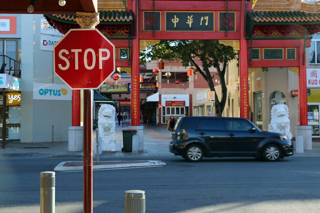

In [8]:
import requests
from PIL import Image
from IPython.display import display

test_url = "https://www.ilankelman.org/stopsigns/australia.jpg"
test_image = Image.open(requests.get(test_url, stream=True).raw).convert("RGB")

answer = generate_answer(model, test_image, "Опиши картинку несколькими словами.")
print("Ответ базовой модели:", answer)
display(test_image.resize((320, 213)))


## 3. Загрузка и подготовка данных `deepvk/GQA-ru`

Датасет хранится в HuggingFace Hub четырьмя конфигурациями:

- `train_balanced_images` — изображения обучающей выборки (id, image);
- `train_balanced_instructions` — вопрос/ответ обучающей выборки (id, imageId, question, answer, fullAnswer);
- `testdev_balanced_images` / `testdev_balanced_instructions` — то же самое для test-dev части.

Вопросы и изображения хранятся в **разных** таблицах и связываются по полю `imageId` (в
таблице вопросов) ↔ `id` (в таблице изображений), поэтому перед обучением нужно построить
соответствие `imageId -> индекс изображения`.


In [ ]:
from datasets import load_dataset, get_dataset_split_names


def load_split_safely(dataset_name, config_name, preferred_split):
    # Пытается загрузить preferred_split; если сплит называется иначе — берёт первый доступный и предупреждает об этом (защита от расхождений в названиях сплитов на HF Hub).
    available = get_dataset_split_names(dataset_name, config_name)
    split = preferred_split if preferred_split in available else available[0]
    if split != preferred_split:
        print(f"[{config_name}] сплит '{preferred_split}' не найден, доступны {available} -> использую '{split}'")
    return load_dataset(dataset_name, config_name, split=split)


In [10]:
gqa_train_images = load_split_safely(GQA_DATASET, "train_balanced_images", "train")
gqa_train_instructions = load_split_safely(GQA_DATASET, "train_balanced_instructions", "train")

print("Изображений в train:", len(gqa_train_images))
print("Вопросов в train:", len(gqa_train_instructions))
print("Пример вопроса:", gqa_train_instructions[0])


README.md: 0.00B [00:00, ?B/s]

train_balanced_images/train-00000-of-000(…):   0%|          | 0.00/3.89G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27519 [00:00<?, ? examples/s]

train_balanced_instructions/train-00000-(…):   0%|          | 0.00/7.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

Изображений в train: 27519
Вопросов в train: 40000
Пример вопроса: {'id': '02633845', 'imageId': '2395730', 'question': 'Кто в рубашке?', 'answer': 'парень', 'fullAnswer': 'Парень в рубашке', 'isBalanced': True, 'groups': {'global': 'person', 'local': '14-shirt_wearing,s'}, 'entailed': '[]', 'equivalent': "['02633845']", 'types': {'structural': 'query', 'semantic': 'rel', 'detailed': 'relS'}, 'annotations': {'question': [{'objectId': '4', 'value': '1203432'}], 'answer': [{'objectId': '0', 'value': '3822894'}], 'fullAnswer': [{'objectId': '1', 'value': '3822894'}, {'objectId': '5', 'value': '1203432'}]}, 'semantic': [{'operation': 'select', 'argument': 'shirt (1203432)', 'dependencies': []}, {'operation': 'relate', 'argument': 'person,wearing,s (3822894)', 'dependencies': [0]}, {'operation': 'query', 'argument': 'name', 'dependencies': [1]}], 'semanticStr': 'select: shirt (1203432)->relate: person,wearing,s (3822894) [0]->query: name [1]'}


In [11]:
# Индекс: imageId (в таблице вопросов) -> позиция в таблице изображений.
# Обращение к столбцу "id" не декодирует картинки, поэтому это быстро даже для 27.5k строк.
gqa_train_image_ids = gqa_train_images["id"]
gqa_train_id_to_idx = {img_id: i for i, img_id in enumerate(gqa_train_image_ids)}
print(f"Построен индекс для {len(gqa_train_id_to_idx)} изображений.")


Построен индекс для 27519 изображений.


## 4. Датасет и коллатор для дообучения (LoRA VQA)

Формат обучающего примера повторяет формат, использованный в оригинальном обучении
`deepvk/llava-gemma-2b-lora` на GQA-ru: вопрос + постпромпт `"Ответь одним словом."`, ответ —
одно слово.

Важная деталь реализации. Токенизация выполняется через processor, а не через tokenizer. Голый токенизатор оставляет в тексте один токен `<image>`, тогда как LlavaForConditionalGeneration ожидает ровно столько плейсхолдеров, сколько визуальных признаков выдаёт CLIP (576 при входе 336×336 и patch_size=14). Несовпадение приводит к ValueError: Image features and image tokens do not match на первом же шаге обучения.
В старых версиях transformers разворачивание выполнялось внутри forward методом _merge_input_ids_with_image_features, который заодно выравнивал labels. В текущих версиях эта логика перенесена в процессор, поэтому длину промпта для маскирования приходится считать вторым вызовом processor — подробности в комментарии к _build_example ниже


In [ ]:
import torch
from torch.utils.data import Dataset


class GQARuVQADataset(Dataset):
    def __init__(self, instructions_ds, images_ds, image_id_to_idx, processor, tokenizer,
                 max_samples=None, max_length=320, post_prompt=POST_PROMPT_GQA, seed=SEED):
        if max_samples is not None and max_samples < len(instructions_ds):
            instructions_ds = instructions_ds.shuffle(seed=seed).select(range(max_samples))
        self.instructions = instructions_ds
        self.images_ds = images_ds
        self.id_to_idx = image_id_to_idx
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.post_prompt = post_prompt

    def __len__(self):
        return len(self.instructions)

    def _build_example(self, idx):
        item = self.instructions[idx]
        img_idx = self.id_to_idx[item["imageId"]]
        image = self.images_ds[img_idx]["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")

        question = str(item["question"]).strip()
        answer = str(item["answer"]).strip()

        messages = [{"role": "user", "content": f"<image>\n{question} {self.post_prompt}"}]
        prompt_text = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        full_text = prompt_text + answer + self.tokenizer.eos_token

        full_inputs = self.processor(
            images=image,
            text=full_text,
            return_tensors="pt",
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
        )
        full_ids = full_inputs["input_ids"][0]
        pixel_values = full_inputs["pixel_values"][0]

        prompt_inputs = self.processor(
            images=image,
            text=prompt_text,
            return_tensors="pt",
            add_special_tokens=False,
        )
        prompt_ids = prompt_inputs["input_ids"][0]

        labels = full_ids.clone()
        prompt_len = min(prompt_ids.shape[0], full_ids.shape[0])
        labels[:prompt_len] = -100

        return {
            "input_ids": full_ids,
            "labels": labels,
            "pixel_values": pixel_values.to(torch.float16),
        }

    def __getitem__(self, idx):
        # защита ОТ RecursionError
        last_exc = None
        for attempt in range(20):
            try:
                return self._build_example((idx + attempt) % len(self))
            except Exception as e:
                last_exc = e
        raise RuntimeError(
            f"Не удалось собрать ни одного рабочего примера, начиная с idx={idx} "
            "(подряд не сработали 20 индексов — похоже на системную ошибку в коде/конфиге, "
            "а не на пару битых картинок). Настоящая причина ниже:"
        ) from last_exc


class VQADataCollator:
    def __init__(self, pad_token_id):
        self.pad_token_id = pad_token_id

    def __call__(self, batch):
        max_len = max(x["input_ids"].shape[0] for x in batch)

        input_ids, attention_mask, labels, pixel_values = [], [], [], []
        for x in batch:
            seq_len = x["input_ids"].shape[0]
            pad_len = max_len - seq_len

            input_ids.append(torch.cat([
                x["input_ids"], torch.full((pad_len,), self.pad_token_id, dtype=torch.long)
            ]))
            attention_mask.append(torch.cat([
                torch.ones(seq_len, dtype=torch.long), torch.zeros(pad_len, dtype=torch.long)
            ]))
            labels.append(torch.cat([
                x["labels"], torch.full((pad_len,), -100, dtype=torch.long)
            ]))
            pixel_values.append(x["pixel_values"])

        return {
            "input_ids": torch.stack(input_ids),
            "attention_mask": torch.stack(attention_mask),
            "labels": torch.stack(labels),
            "pixel_values": torch.stack(pixel_values),
        }


In [13]:
train_dataset = GQARuVQADataset(
    instructions_ds=gqa_train_instructions,
    images_ds=gqa_train_images,
    image_id_to_idx=gqa_train_id_to_idx,
    processor=processor,
    tokenizer=tokenizer,
    max_samples=MAX_TRAIN_SAMPLES,
    max_length=MAX_SEQ_LENGTH,
)
collator = VQADataCollator(pad_token_id=tokenizer.pad_token_id)

print(f"Размер обучающей выборки: {len(train_dataset)}")

sample = train_dataset[0]
print("input_ids shape:", sample["input_ids"].shape)
print("pixel_values shape:", sample["pixel_values"].shape)
print("Доля токенов, участвующих в лоссе (labels != -100):",
      round((sample["labels"] != -100).float().mean().item(), 3))


Размер обучающей выборки: 4000
input_ids shape: torch.Size([600])
pixel_values shape: torch.Size([3, 336, 336])
Доля токенов, участвующих в лоссе (labels != -100): 0.003


## 5. Настройка LoRA (PEFT)

LoRA-адаптеры навешиваются **только на языковую часть** модели (`language_model.*`,
attention- и MLP-проекции Gemma: `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj,
down_proj`). Vision-энкодер и проектор остаются полностью замороженными — это стандартный и
эффективный по времени/памяти подход для дообучения VLM под конкретную предметную область
(в данном случае — русский язык), когда визуальные признаки уже достаточно хороши.


In [ ]:
import re
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# gradient checkpointing включаем через prepare_model_for_kbit_training,
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

LORA_TARGET_REGEX = r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$"

candidate_modules = [n for n, _ in model.named_modules() if re.match(LORA_TARGET_REGEX, n)]
print(f"Найдено {len(candidate_modules)} целевых модулей для LoRA (только language_model):")
for name in candidate_modules[:8]:
    print(" -", name)
print(" ...")

assert len(candidate_modules) > 0, "Не найдено модулей для LoRA — проверьте архитектуру модели (model.named_modules())"
assert all("vision_tower" not in n for n in candidate_modules), "В LoRA попал vision_tower — проверьте регулярное выражение"


Найдено 126 целевых модулей для LoRA (только language_model):
 - model.language_model.layers.0.self_attn.q_proj
 - model.language_model.layers.0.self_attn.k_proj
 - model.language_model.layers.0.self_attn.v_proj
 - model.language_model.layers.0.self_attn.o_proj
 - model.language_model.layers.0.mlp.gate_proj
 - model.language_model.layers.0.mlp.up_proj
 - model.language_model.layers.0.mlp.down_proj
 - model.language_model.layers.1.self_attn.q_proj
 ...


In [15]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=LORA_TARGET_REGEX,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 19,611,648 || all params: 2,835,718,144 || trainable%: 0.6916


## 6. Дообучение (fine-tuning)

Обучение оптимизировано по времени/памяти:

- модель загружена в 4-bit, LoRA обучает только небольшой набор адаптеров;
- `gradient_checkpointing=True` — экономит память ценой немного большего времени на шаг;
- `optim="paged_adamw_8bit"` — 8-битный оптимизатор из `bitsandbytes`, снижает потребление памяти;
- по умолчанию используется подвыборка `MAX_TRAIN_SAMPLES` из 40k обучающих примеров
  (см. раздел 0.2) — этого достаточно, чтобы увидеть явное снижение loss и рабочий адаптер
  в пределах одного сеанса Colab.


In [16]:
from transformers import TrainingArguments, Trainer
import time

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    fp16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    gradient_checkpointing=False,  # уже включён выше через prepare_model_for_kbit_training
)

model.config.use_cache = False  # обязательно при gradient checkpointing

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collator,
)

print(f"Начинаем обучение на {len(train_dataset)} примерах "
      f"({NUM_TRAIN_EPOCHS} эпох(а), эффективный batch size = "
      f"{PER_DEVICE_TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS})")

start_time = time.time()
train_result = trainer.train()
elapsed_min = (time.time() - start_time) / 60
print(f"\nОбучение завершено за {elapsed_min:.1f} минут.")
print(f"Финальный training loss: {train_result.training_loss:.4f}")


Начинаем обучение на 4000 примерах (1 эпох(а), эффективный batch size = 16)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,6.016400
20,0.778600
30,1.068600
40,0.802200
50,0.600400
60,0.570000
70,0.709500
80,0.655100
90,0.730000
100,0.771400



Обучение завершено за 60.5 минут.
Финальный training loss: 0.8881


In [17]:
model.config.use_cache = True  # включаем обратно для быстрой генерации на инференсе

model.save_pretrained(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA-адаптер и процессор сохранены в: {ADAPTER_DIR}")


LoRA-адаптер и процессор сохранены в: ./llava-gemma-2b-lora-gqa-ru-adapter


## 7. График функции потерь (Loss)


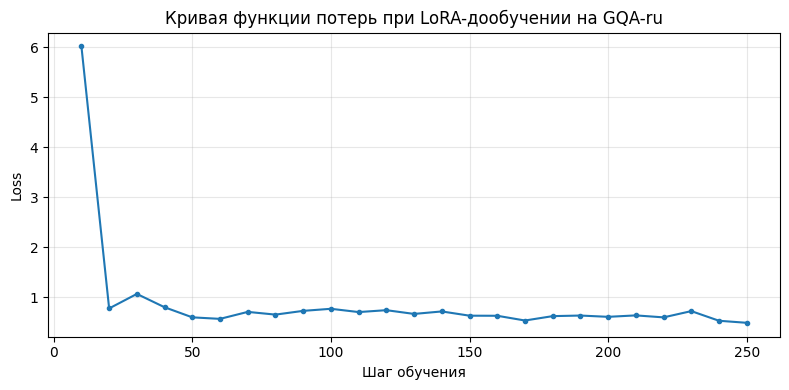

Loss на первом залогированном шаге: 6.0164
Loss на последнем залогированном шаге: 0.4913


In [18]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [x["step"] for x in log_history if "loss" in x]
losses = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", markersize=3)
plt.xlabel("Шаг обучения")
plt.ylabel("Loss")
plt.title("Кривая функции потерь при LoRA-дообучении на GQA-ru")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print(f"Loss на первом залогированном шаге: {losses[0]:.4f}" if losses else "Нет данных о loss")
print(f"Loss на последнем залогированном шаге: {losses[-1]:.4f}" if losses else "")


## 8. Сравнение "До / После" на примерах

Благодаря тому, что дообучение выполнено через LoRA (`peft`), можно получить ответ **базовой**
модели, временно отключив адаптеры контекстным менеджером `model.disable_adapter()` — без
повторной загрузки второй копии модели (экономия времени и памяти).

Ниже — примеры из test-dev части `deepvk/GQA-ru` (тот же стиль вопросов, что и при обучении).


In [19]:
gqa_testdev_instructions = load_split_safely(GQA_DATASET, "testdev_balanced_instructions", "testdev")
gqa_testdev_images = load_split_safely(GQA_DATASET, "testdev_balanced_images", "testdev")
gqa_testdev_id_to_idx = {img_id: i for i, img_id in enumerate(gqa_testdev_images["id"])}

print("Вопросов в testdev:", len(gqa_testdev_instructions))
print("Изображений в testdev:", len(gqa_testdev_images))


testdev_balanced_instructions/testdev-00(…):   0%|          | 0.00/1.95M [00:00<?, ?B/s]

Generating testdev split:   0%|          | 0/12216 [00:00<?, ? examples/s]

testdev_balanced_images/testdev-00000-of(…):   0%|          | 0.00/65.6M [00:00<?, ?B/s]

Generating testdev split:   0%|          | 0/398 [00:00<?, ? examples/s]

Вопросов в testdev: 12216
Изображений в testdev: 398


Caching is incompatible with gradient checkpointing in GemmaDecoderLayer. Setting `past_key_values=None`.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


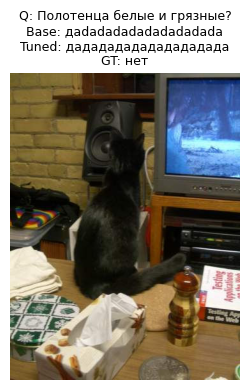

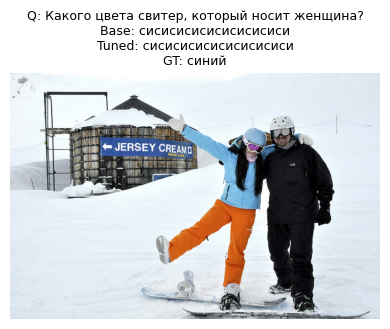

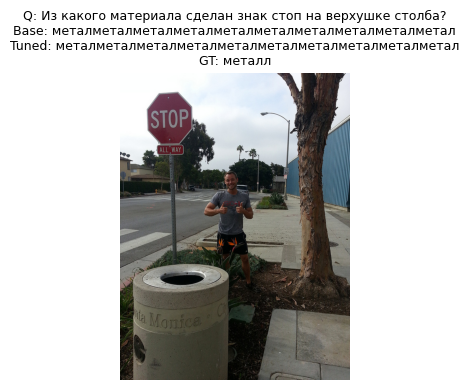

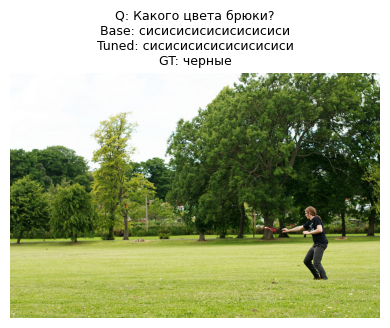

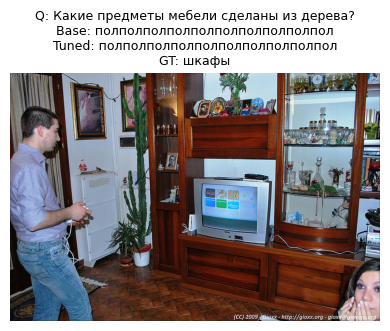

In [20]:
def show_comparison(image, question, base_answer, tuned_answer, gt_answer=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    title = f"Q: {question}\nBase: {base_answer}\nTuned: {tuned_answer}"
    if gt_answer is not None:
        title += f"\nGT: {gt_answer}"
    plt.title(title, fontsize=9)
    plt.tight_layout()
    plt.show()


random.seed(SEED)
qualitative_indices = random.sample(range(len(gqa_testdev_instructions)), NUM_QUALITATIVE_EXAMPLES)

for idx in qualitative_indices:
    item = gqa_testdev_instructions[idx]
    image = gqa_testdev_images[gqa_testdev_id_to_idx[item["imageId"]]]["image"]
    if image.mode != "RGB":
        image = image.convert("RGB")
    question = str(item["question"]).strip()
    gt = str(item["answer"]).strip()

    with model.disable_adapter():
        base_ans = generate_answer(model, image, f"{question} {POST_PROMPT_GQA}", max_new_tokens=10)
    tuned_ans = generate_answer(model, image, f"{question} {POST_PROMPT_GQA}", max_new_tokens=10)

    show_comparison(image, question, base_ans, tuned_ans, gt)


## 9. Количественная оценка на `deepvk/MMBench-ru`

`MMBench-ru` — тест с вариантами ответа (2–4 варианта: `A/B/C/D`, некоторые вопросы содержат
`hint`). Модель просят ответить одной буквой, ответ парсится и сравнивается с правильным
вариантом (`answer`). Это даёт accuracy — метрику **обобщения** модели на формат вопросов,
отличный от того, на котором она дообучалась (в обучении использовались открытые
однословные ответы GQA-ru, а не выбор из вариантов).

Для скорости по умолчанию оценка идёт на случайной подвыборке `EVAL_MMBENCH_SAMPLES` из
3910 примеров.


In [21]:
mmbench_ds = load_split_safely(MMBENCH_DATASET, "default", "dev")
print("Вопросов в MMBench-ru (dev):", len(mmbench_ds))
print("Пример:", {k: v for k, v in mmbench_ds[0].items() if k != "image"})


README.md: 0.00B [00:00, ?B/s]

mmbench_ru_dev.parquet:   0%|          | 0.00/92.7M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/3910 [00:00<?, ? examples/s]

Вопросов в MMBench-ru (dev): 3910
Пример: {'index': 267, 'question': 'Какая часть яблони может вырасти в новое дерево?', 'hint': 'На этой диаграмме показан жизненный цикл яблони.', 'A': 'семя', 'B': 'лист', 'C': 'nan', 'D': 'nan', 'answer': 'A', 'category': 'physical_property_reasoning', 'source': 'scienceqa', 'l2-category': 'attribute_reasoning', 'comment': 'nan', 'split': 'dev'}


In [22]:
from tqdm.auto import tqdm
import pandas as pd


def format_mmbench_prompt(row):
    parts = []
    hint = row.get("hint")
    if hint is not None and str(hint).strip().lower() not in ("", "nan", "none"):
        parts.append(str(hint).strip())
    parts.append(str(row["question"]).strip())

    letters = []
    for letter in ["A", "B", "C", "D"]:
        opt = row.get(letter)
        if opt is not None and str(opt).strip().lower() not in ("", "nan", "none"):
            parts.append(f"{letter}. {str(opt).strip()}")
            letters.append(letter)

    parts.append("Выбери один правильный вариант ответа и напиши только его букву (A, B, C или D).")
    return "\n".join(parts), letters


def parse_letter(generated_text, allowed_letters):
    generated_text = generated_text.strip().upper()
    for ch in generated_text:
        if ch in allowed_letters:
            return ch
    return None


def evaluate_mmbench(gen_model, dataset, n_samples, seed=SEED, desc="model"):
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), min(n_samples, len(dataset)))
    correct, total = 0, 0
    for idx in tqdm(indices, desc=desc):
        row = dataset[idx]
        prompt, letters = format_mmbench_prompt(row)
        image = row["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        pred_text = generate_answer(gen_model, image, prompt, max_new_tokens=5)
        pred_letter = parse_letter(pred_text, letters)
        gt = row["answer"]
        total += 1
        if pred_letter == gt:
            correct += 1
    acc = correct / total if total else 0.0
    print(f"[{desc}] MMBench-ru accuracy: {acc:.3f}  ({correct}/{total})")
    return acc


In [23]:
print("Оценка БАЗОВОЙ модели на MMBench-ru...")
with model.disable_adapter():
    acc_base_mmbench = evaluate_mmbench(model, mmbench_ds, n_samples=EVAL_MMBENCH_SAMPLES, desc="base")

print("\nОценка ДООБУЧЕННОЙ модели на MMBench-ru...")
acc_tuned_mmbench = evaluate_mmbench(model, mmbench_ds, n_samples=EVAL_MMBENCH_SAMPLES, desc="tuned")

results_mmbench = pd.DataFrame({
    "model": ["base (без LoRA)", "tuned (с LoRA)"],
    "MMBench-ru_accuracy": [acc_base_mmbench, acc_tuned_mmbench],
})
results_mmbench


Оценка БАЗОВОЙ модели на MMBench-ru...


base:   0%|          | 0/200 [00:00<?, ?it/s]

[base] MMBench-ru accuracy: 0.630  (126/200)

Оценка ДООБУЧЕННОЙ модели на MMBench-ru...


tuned:   0%|          | 0/200 [00:00<?, ?it/s]

[tuned] MMBench-ru accuracy: 0.645  (129/200)


,model,MMBench-ru_accuracy
0,base (без LoRA),0.630
1,tuned (с LoRA),0.645


## 10. Количественная оценка на `deepvk/GQA-ru` (testdev, Exact Match)

Дополнительно — оценка **в домене** обучения: одно-словные ответы GQA-ru, метрика Exact Match
(сгенерированный ответ должен точно совпасть с эталонным словом), как в оригинальной методике
`lmms-eval`, использованной при обучении `deepvk/llava-gemma-2b-lora`.


In [24]:
def evaluate_gqa_exact_match(gen_model, instructions_ds, images_ds, id_to_idx, n_samples, seed=SEED, desc="model"):
    rng = random.Random(seed)
    indices = rng.sample(range(len(instructions_ds)), min(n_samples, len(instructions_ds)))
    correct, total = 0, 0
    for idx in tqdm(indices, desc=desc):
        item = instructions_ds[idx]
        image = images_ds[id_to_idx[item["imageId"]]]["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")
        question = str(item["question"]).strip()
        gt = str(item["answer"]).strip().lower()

        pred = generate_answer(gen_model, image, f"{question} {POST_PROMPT_GQA}", max_new_tokens=8)
        pred = pred.strip().lower()
        pred = pred.split()[0].strip(".,!?") if pred.split() else pred

        total += 1
        if pred == gt:
            correct += 1
    acc = correct / total if total else 0.0
    print(f"[{desc}] GQA-ru testdev ExactMatch: {acc:.3f}  ({correct}/{total})")
    return acc


In [25]:
print("Оценка БАЗОВОЙ модели на GQA-ru testdev...")
with model.disable_adapter():
    acc_base_gqa = evaluate_gqa_exact_match(
        model, gqa_testdev_instructions, gqa_testdev_images, gqa_testdev_id_to_idx,
        n_samples=EVAL_GQA_TESTDEV_SAMPLES, desc="base",
    )

print("\nОценка ДООБУЧЕННОЙ модели на GQA-ru testdev...")
acc_tuned_gqa = evaluate_gqa_exact_match(
    model, gqa_testdev_instructions, gqa_testdev_images, gqa_testdev_id_to_idx,
    n_samples=EVAL_GQA_TESTDEV_SAMPLES, desc="tuned",
)

results_gqa = pd.DataFrame({
    "model": ["base (без LoRA)", "tuned (с LoRA)"],
    "GQA-ru_testdev_ExactMatch": [acc_base_gqa, acc_tuned_gqa],
})
results_gqa


Оценка БАЗОВОЙ модели на GQA-ru testdev...


base:   0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[base] GQA-ru testdev ExactMatch: 0.000  (0/200)

Оценка ДООБУЧЕННОЙ модели на GQA-ru testdev...


tuned:   0%|          | 0/200 [00:00<?, ?it/s]

[tuned] GQA-ru testdev ExactMatch: 0.005  (1/200)


,model,GQA-ru_testdev_ExactMatch
0,base (без LoRA),0.000
1,tuned (с LoRA),0.005


In [26]:
final_results = results_mmbench.merge(results_gqa, on="model")
final_results.to_csv("results_summary.csv", index=False)
print("Итоговая таблица сохранена в results_summary.csv")
final_results


Итоговая таблица сохранена в results_summary.csv


,model,MMBench-ru_accuracy,GQA-ru_testdev_ExactMatch
0,base (без LoRA),0.630,0.000
1,tuned (с LoRA),0.645,0.005


## 11. Итоги и ограничения этапа обучения

Этот ноутбук покрывает подготовку данных и обучение адаптера. Оценка качества вынесена
в `02_eval.ipynb`, итоговые выводы — в `README.md` и `docs/REPORT.md`.

### Итоги

- Загружена базовая модель `deepvk/llava-gemma-2b-lora` (LLaVA поверх `google/gemma-2b-it`)
  в 4-битном квантовании NF4.
- На подвыборке из 4000 примеров `deepvk/GQA-ru` (train, `seed = 42`) обучен LoRA-адаптер
  поверх языковой части: 19 611 648 параметров из 2 835 718 144, то есть 0.69%.
- Обучение заняло 60.5 минут на Tesla T4: 250 шагов оптимизатора при эффективном
  батче 16, одна эпоха.
- Функция потерь: 6.02 на первом залогированном шаге → 0.49 на последнем, среднее по всем
  шагам 0.8881 (раздел 7). Резкое падение приходится на первые ~20 шагов.
- Адаптер сохранён в `llava-gemma-2b-lora-gqa-ru-adapter/` (78.5 МБ).

### Внимание: разделы 8–10 содержат некорректную оценку

Оценка в разделах 8–10 выполнялась сразу после `trainer.train()`, когда модель оставалась
в режиме `train()` с активным gradient checkpointing. Из-за этого отключался KV-кэш,
а `pixel_values` передавались в `forward` только на первом шаге генерации — начиная со
второго токена изображение исчезало из контекста. Валиден только первый сгенерированный
токен, поэтому `GQA-ru` дал 0.000, а `MMBench-ru`, где нужна одна буква, «выжил».

Разделы оставлены без изменений намеренно: они документируют ошибку и способ её
обнаружения. Разбор механизма — `docs/REPORT.md`, раздел 7.1. Корректные метрики —
`02_eval.ipynb`.

### Ограничения этапа обучения

- **Размер обучающей выборки.** Использовано 4000 примеров из 40 000 и одна эпоха. Полный
  сплит потребовал бы около 2500 шагов, порядка 10 часов при текущей скорости. Увеличение
  выборки, однако, вряд ли даст прирост: train-сплит `GQA-ru` уже использовался авторами
  базовой модели с тем же пост-промптом на этапе instruction tuning — см. `docs/REPORT.md`,
  раздел 3.3.
- **Разреженность обучающего сигнала.** Доля токенов, участвующих в функции потерь, — 0.003,
  около 2 токенов из 600: ответы однословные, промпт замаскирован целиком.
- **Формат «выбор из вариантов» отсутствует в обучающих данных.** Модель не видела формата
  MMBench-ru, поэтому точность на нём отражает в первую очередь способность следовать
  инструкции «ответь буквой», а не качество рассуждений. Оценка это подтвердила. Для
  целенаправленного улучшения бенчмарка нужны данные в формате multiple-choice, например
  `deepvk/LLaVA-Instruct-ru`.
- **Визуальный энкодер заморожен.** LoRA применяется только к языковой части — быстро и
  экономно по памяти, но не позволяет адаптировать сами визуальные признаки. Часть ошибок,
  в частности путаница «слева» / «справа», этим методом неустранима.
- **Нет валидационного сплита.** Обучение шло фиксированные 250 шагов без отбора лучшего
  чекпоинта.

In [29]:
# Собираем все артефакты прогона в один архив: LoRA-адаптер (веса + processor/tokenizer),
# график loss и итоговую таблицу метрик.
import os
import shutil

SUBMISSION_DIR = "submission_bundle"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

if os.path.isdir(ADAPTER_DIR):
    shutil.copytree(
        ADAPTER_DIR,
        os.path.join(SUBMISSION_DIR, os.path.basename(ADAPTER_DIR.rstrip("/"))),
        dirs_exist_ok=True,
    )
    print(f"Адаптер скопирован из {ADAPTER_DIR}")
else:
    print(f"Внимание: папка с адаптером {ADAPTER_DIR} не найдена — сначала выполните раздел 6.")

for fname in ["loss_curve.png", "results_summary.csv"]:
    if os.path.exists(fname):
        shutil.copy(fname, SUBMISSION_DIR)
        print(f"{fname} скопирован")
    else:
        print(f"Внимание: файл {fname} не найден — выполните соответствующий раздел выше.")

archive_path = shutil.make_archive("submission_bundle", "zip", SUBMISSION_DIR)
print(f"\nАрхив собран: {archive_path} ({os.path.getsize(archive_path) / 1e6:.1f} МБ)")

Адаптер скопирован из ./llava-gemma-2b-lora-gqa-ru-adapter
loss_curve.png скопирован
results_summary.csv скопирован

Архив собран: /content/submission_bundle.zip (80.3 МБ)


In [ ]:
try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Похоже, ноутбук выполняется не в Google Colab — "
          "скачайте submission_bundle.zip вручную через панель Files слева "
          "(правый клик по файлу → Download).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# сохранить архив прямо в Google Drive.
from google.colab import drive
drive.mount('/content/drive')

DRIVE_SAVE_DIR = "/content/drive/MyDrive/llava-gemma-gqa-ru"  
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
shutil.copy(archive_path, DRIVE_SAVE_DIR)
print(f"Архив скопирован в Google Drive: {DRIVE_SAVE_DIR}/{os.path.basename(archive_path)}")


Mounted at /content/drive
Архив скопирован в Google Drive: /content/drive/MyDrive/llava-gemma-gqa-ru/submission_bundle.zip


In [ ]:
import os
import shutil

# 1. Собираем отдельный архив с чекпоинтами Trainer
if os.path.isdir(OUTPUT_DIR):
    checkpoints_archive_path = shutil.make_archive("trainer_checkpoints", "zip", OUTPUT_DIR)
    print(f"Архив с чекпоинтами собран: {checkpoints_archive_path} "
          f"({os.path.getsize(checkpoints_archive_path) / 1e6:.1f} МБ)")
else:
    print(f"Внимание: {OUTPUT_DIR} не найден — похоже, раздел 6 (обучение) "
          "ещё не выполнялся в этой сессии.")

# 2. Копируем его на Google Drive (отдельным файлом, не смешивая с submission_bundle.zip)
from google.colab import drive
drive.mount('/content/drive') 

DRIVE_SAVE_DIR = "/content/drive/MyDrive/llava-gemma-gqa-ru"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
shutil.copy(checkpoints_archive_path, DRIVE_SAVE_DIR)
print(f"Архив с чекпоинтами скопирован в Google Drive: "
      f"{DRIVE_SAVE_DIR}/{os.path.basename(checkpoints_archive_path)}")

Архив с чекпоинтами собран: /content/trainer_checkpoints.zip (216.3 МБ)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Архив с чекпоинтами скопирован в Google Drive: /content/drive/MyDrive/llava-gemma-gqa-ru/trainer_checkpoints.zip
